Name: Athena S. Villarin <br>
Year and Section: BSCS 3-A AI <br>
Date: April 10, 2026 <br>

In [124]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Paste the Wikipedia link you want to use here. 
# The article should be reasonably long (at least a few thousand words) for good results.
WIKI_URL = "https://en.wikipedia.org/wiki/Chess"
RANDOM_SEED = 42

In [125]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

In [126]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Chess-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [127]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

In [128]:
def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

In [129]:
def train_sgns(sentences: List[List[str]], vector_size=100, window=5) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,  # What happens if we change this? Try 50, 200, 300 and see how it affects results.
        window=window,
        min_count=1,
        workers=4,
        sg=1,          # 0 = CBOW, 1 = skip-gram
        negative=10,   # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

In [130]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index

def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }

def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }

def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

## Main Execution

In [131]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
ensure_nltk()

print("Downloading Wikipedia article...")
raw_text = fetch_wikipedia_article(WIKI_URL)

print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"{k}: {v}")

Preprocessing text...

=== Corpus Stats ===
num_sentences: 1072
num_tokens: 17117
vocab_size: 3757


In [132]:
print("\nTraining Skip-gram with Negative Sampling...")
model = train_sgns(sentences)

print("\nVocabulary size learned:", len(model.wv))


Training Skip-gram with Negative Sampling...

Vocabulary size learned: 3757


In [133]:
probe_words = [
    "chess", "game", "board", "player", "move",
    "piece", "king", "queen", "pawn", "rook"
]
print_top_neighbors(model, probe_words, topn=8)


=== Nearest Neighbors ===

chess:
  millennium           0.4998
  infinite             0.4876
  minichess            0.4858
  masonic              0.4855
  beirut               0.4853
  circe                0.4848
  chessplus            0.4809
  atomic               0.4804

game:
  drawn                0.5731
  opera                0.5280
  friends              0.5140
  peruvian             0.5059
  evergreen            0.5022
  jungle               0.4913
  kingdoms             0.4888
  banqi                0.4880

board:
  bock-raming          0.7017
  andreas              0.6999
  gaming               0.6966
  terminological       0.6892
  geometries           0.6861
  monochrome           0.6770
  pada                 0.6767
  plain                0.6758

player:
  titled               0.5287
  kitab                0.5282
  renowned             0.5241
  paired               0.5127
  ash-shatranj         0.5108
  submit               0.5086
  mathematician        0.5072
  emanuel  

In [134]:
relatedness_test = [
    ("chess", "game", 0.95),
    ("king", "queen", 0.90),
    ("pawn", "piece", 0.85),
    ("board", "game", 0.80),
    ("player", "move", 0.75),
    ("rook", "bishop", 0.70),
    ("chess", "sport", 0.60),
    ("king", "pawn", 0.50),
    ("chess", "kitchen", 0.05),
    ("player", "tractor", 0.02),
    ("board", "movie", 0.25),
    ("piece", "pilot", 0.30),
]

rel_results = evaluate_relatedness(model, relatedness_test)

print("\n=== Relatedness Test Set ===")
print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
for w1, w2, gold, pred in rel_results["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")


=== Relatedness Test Set ===
Coverage: 8/12
chess      - game       | gold=0.95 pred=0.1892
king       - queen      | gold=0.90 pred=0.4068
pawn       - piece      | gold=0.85 pred=0.2985
board      - game       | gold=0.80 pred=0.2430
player     - move       | gold=0.75 pred=0.2761
rook       - bishop     | gold=0.70 pred=0.6433
chess      - sport      | gold=0.60 pred=0.2904
king       - pawn       | gold=0.50 pred=0.3280


In [135]:
# Small analogy-style test set
analogy_test = [
    ("king", "queen", "pawn", "piece"),
    ("board", "game", "player", "move"),
    ("chess", "game", "sport", "athlete"),
    ("rook", "castle", "bishop", "diagonal"),
]

analogy_results = evaluate_analogies(model, analogy_test)

print("\n=== Analogy Test Set ===")
print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
for item in analogy_results["details"]:
    print(json.dumps(item, ensure_ascii=False))


=== Analogy Test Set ===
Coverage: 3/4
Top-5 accuracy: 0.0
{"analogy": "king:queen::pawn:?", "expected": "piece", "predictions": ["alfil", "camel", "amazon", "hedgehog", "dabbaba"], "correct_in_top5": false}
{"analogy": "board:game::player:?", "expected": "move", "predictions": ["qualify", "resigns", "usual", "drawn", "resigned"], "correct_in_top5": false}
{"analogy": "rook:castle::bishop:?", "expected": "diagonal", "predictions": ["once", "wherever", "per", "giuoco", "cylinder"], "correct_in_top5": false}


In [136]:
# Example direct similarity checks
print("\n=== Direct Similarity Checks ===")
check_pairs = [
    ("chess", "game"),
    ("king", "queen"),
    ("pawn", "piece"),
    ("chess", "kitchen"),
]
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")


=== Direct Similarity Checks ===
chess      <-> game      : 0.1892
king       <-> queen     : 0.4068
pawn       <-> piece     : 0.2985
chess      <-> kitchen   : OOV


## Retrain with New Configuration (Window Size 10)

In [137]:
print("\nRetraining with window=10...")
model_new = train_sgns(sentences, window=10)

print("\nVocabulary size learned (new):", len(model_new.wv))

# Compare relatedness
rel_results_new = evaluate_relatedness(model_new, relatedness_test)
print("\n=== Relatedness Comparison ===")
print("Original (window=5):")
print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
for w1, w2, gold, pred in rel_results["covered_items"][:5]:  # Show first 5
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

print("\nNew (window=10):")
print(f"Coverage: {rel_results_new['coverage']}/{rel_results_new['total']}")
for w1, w2, gold, pred in rel_results_new["covered_items"][:5]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")


Retraining with window=10...

Vocabulary size learned (new): 3757

=== Relatedness Comparison ===
Original (window=5):
Coverage: 8/12
chess      - game       | gold=0.95 pred=0.1892
king       - queen      | gold=0.90 pred=0.4068
pawn       - piece      | gold=0.85 pred=0.2985
board      - game       | gold=0.80 pred=0.2430
player     - move       | gold=0.75 pred=0.2761

New (window=10):
Coverage: 8/12
chess      - game       | gold=0.95 pred=0.2038
king       - queen      | gold=0.90 pred=0.4391
pawn       - piece      | gold=0.85 pred=0.3054
board      - game       | gold=0.80 pred=0.2246
player     - move       | gold=0.75 pred=0.2394


## PCA Visualization

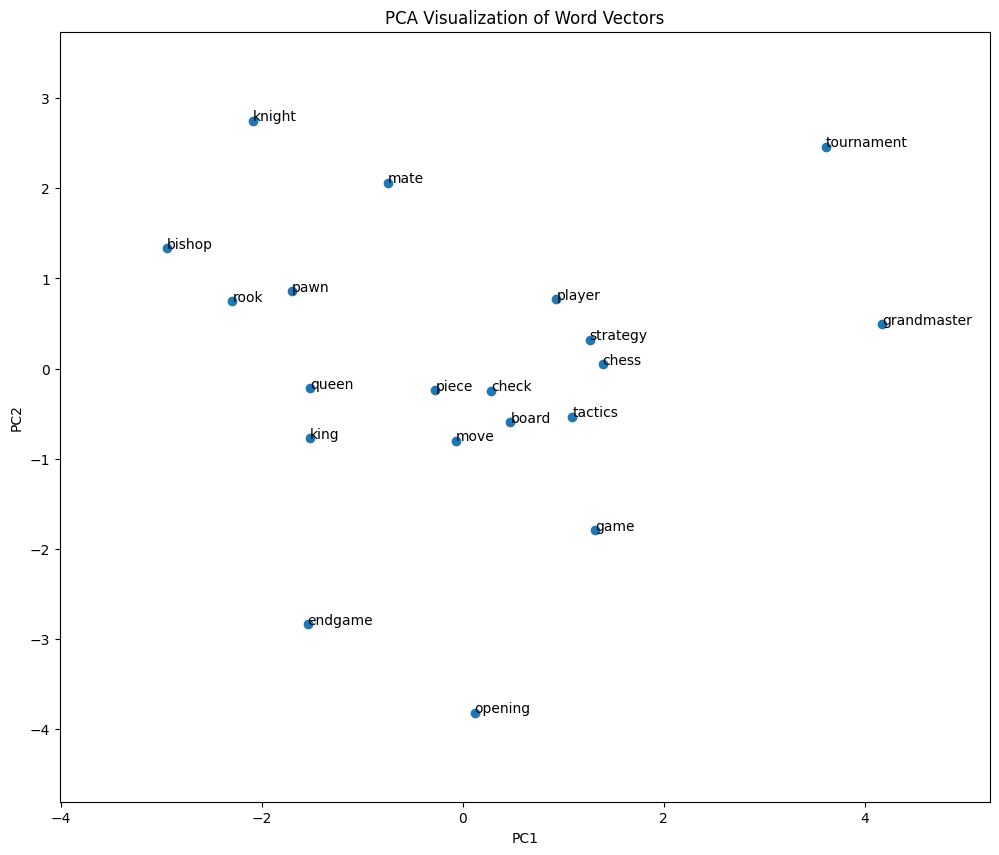

In [138]:
# Selected words
words_to_plot = [w for w in [
    "chess", "game", "board", "player", "move", "piece", "king", "queen", "pawn", "rook",
    "bishop", "knight", "check", "mate", "opening", "endgame", "tournament", "grandmaster",
    "strategy", "tactics"
] if has_word(model, w)][:20]

if len(words_to_plot) < 20:
    all_words = list(model.wv.key_to_index.keys())[:20 - len(words_to_plot)]
    words_to_plot.extend(all_words)

vectors = np.array([model.wv[word] for word in words_to_plot])

# PCA to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
plt.margins(0.15)

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title("PCA Visualization of Word Vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()